# HW14 — Embeddings, FAISS, retrieval evaluation, knowledge base updates and mini-RAG

Этот ноутбук реализует полный учебный pipeline для HW14:

- небольшая воспроизводимая база знаний;
- чанкинг документов;
- векторные представления текстовых фрагментов;
- индекс **FAISS**;
- набор контрольных запросов и оценка качества retrieval;
- небольшой эксперимент с параметрами;
- обновление базы знаний и переиндексация;
- простой **mini-RAG** с возвратом источников.

In [1]:
import os
import re
import sys
import json
import math
import random
from pathlib import Path
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

import faiss


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS:", faiss.__version__)

Python: 3.13.5
NumPy: 2.1.3
Pandas: 2.2.3
FAISS: 1.13.2


## 1. База знаний и первичный анализ

В качестве базы знаний используем небольшой корпус документов по одной понятной теме:  
**эмбеддинги, retrieval, FAISS, оценка качества retrieval и mini-RAG**.

Почему эта предметная область подходит:
- документы тематически связаны;
- по ним удобно задавать фактологические и концептуальные вопросы;
- база достаточно компактна для учебного запуска;
- после чанкинга получается разумное число фрагментов для FAISS-поиска.


In [2]:
documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_01",
        "title": "Что такое эмбеддинги",
        "text": (
            "Эмбеддинги текста — это числовые векторные представления, в которых похожие по смыслу фразы "
            "располагаются ближе друг к другу. В retrieval-задачах запрос и документы переводят в одно "
            "векторное пространство, после чего ищут ближайшие фрагменты по косинусной близости или "
            "скалярному произведению. Хорошие эмбеддинги позволяют находить смыслово релевантные фрагменты, "
            "даже если в запросе и документе используются разные слова."
        ),
    },
    {
        "doc_id": "doc_02",
        "title": "Почему retrieval отличается от классификации",
        "text": (
            "В классификации модель должна предсказать метку для входного текста. В retrieval задача другая: "
            "не выбрать класс, а найти релевантные документы или чанки знаний. Поэтому качество retrieval "
            "оценивают не accuracy, а метриками вроде hit@k, recall@k и MRR. Retrieval является отдельным "
            "инженерным слоем и часто используется как подготовительный этап перед генерацией ответа в RAG."
        ),
    },
    {
        "doc_id": "doc_03",
        "title": "Зачем нужен чанкинг",
        "text": (
            "Длинные документы редко индексируют целиком, потому что один большой текст смешивает несколько тем. "
            "Обычно документ делят на небольшие чанки. Это повышает точность поиска и помогает вернуть более "
            "локальный контекст. Если chunk_size слишком велик, retrieval становится размытым. Если chunk_size "
            "слишком мал, фрагмент может потерять важную информацию. overlap помогает сохранить связь между соседними частями."
        ),
    },
    {
        "doc_id": "doc_04",
        "title": "Что такое FAISS",
        "text": (
            "FAISS — библиотека для поиска ближайших соседей по векторам. В учебном сценарии часто используют "
            "индекс IndexFlatIP или IndexFlatL2. Если векторы заранее нормализованы, IndexFlatIP удобно применять "
            "для поиска по косинусной близости. FAISS позволяет быстро возвращать top-k ближайших фрагментов и "
            "служит базовым инструментом для локального retrieval без внешней векторной базы."
        ),
    },
    {
        "doc_id": "doc_05",
        "title": "Контрольные запросы и benchmark",
        "text": (
            "Для оценки retrieval нужен небольшой benchmark. Он состоит из запросов и заранее размеченных "
            "релевантных источников. Для каждого запроса полезно указать ожидаемый документ или набор документов. "
            "Даже маленький benchmark из 8–12 запросов уже позволяет понять, где retriever работает хорошо, "
            "а где ошибается. Без контрольных запросов retrieval сложно оценивать инженерно."
        ),
    },
    {
        "doc_id": "doc_06",
        "title": "Метрики retrieval",
        "text": (
            "Hit@k показывает, попал ли хотя бы один релевантный источник в top-k. Recall@k показывает, какую "
            "долю релевантных источников удалось найти среди top-k результатов. MRR@k учитывает позицию первого "
            "релевантного ответа: чем он выше в выдаче, тем лучше. Эти метрики подходят для retrieval лучше, чем "
            "обычные классификационные показатели."
        ),
    },
    {
        "doc_id": "doc_07",
        "title": "Влияние top-k на качество",
        "text": (
            "Параметр top-k управляет количеством извлекаемых фрагментов. Малое top-k уменьшает шум, но может "
            "не включить нужный контекст. Слишком большое top-k повышает шанс найти релевантный источник, но "
            "одновременно приносит лишние и дублирующиеся чанки. Поэтому top-k обычно подбирают как компромисс "
            "между полнотой и чистотой контекста."
        ),
    },
    {
        "doc_id": "doc_08",
        "title": "Обновление базы знаний",
        "text": (
            "Если в базе знаний появились новые документы или изменения в существующих, retriever нужно обновить. "
            "Обычно это означает повторный чанкинг новых текстов, пересчёт векторных представлений и переиндексацию. "
            "Без обновления индекс не знает о новых фактах, поэтому retrieval не сможет вернуть свежий источник. "
            "В учебной работе важно показать результат до обновления и после него."
        ),
    },
    {
        "doc_id": "doc_09",
        "title": "Как работает mini-RAG",
        "text": (
            "Mini-RAG можно представить как цепочку: вопрос пользователя, retrieval релевантных чанков, сборка "
            "контекста, формирование ответа по найденным фрагментам и возврат источников. Качество ответа зависит "
            "не только от генератора, но и от качества retrieval. Если релевантный фрагмент не найден, генератор "
            "часто начинает отвечать неполно или уверенно ошибается."
        ),
    },
    {
        "doc_id": "doc_10",
        "title": "Ограничения учебного RAG",
        "text": (
            "Учебный RAG обычно работает без reranking, без внешней векторной базы и без тяжёлой LLM-инфраструктуры. "
            "Из-за этого он чувствителен к формулировке запроса, качеству чанкинга и полноте базы знаний. "
            "Шумный контекст тоже ухудшает ответ. Поэтому важно анализировать ошибки и явно отделять проблемы "
            "retrieval от проблем генерации."
        ),
    },
    {
        "doc_id": "doc_11",
        "title": "Почему полезен overlap",
        "text": (
            "Overlap — это пересечение между соседними чанками. Он помогает не потерять смысловые переходы на "
            "границе фрагментов. Если важное определение начинается в конце одного чанка и продолжается в следующем, "
            "overlap повышает шанс, что retrieval всё равно найдёт достаточный контекст. Слишком большой overlap, "
            "однако, создаёт много похожих дублей."
        ),
    },
    {
        "doc_id": "doc_12",
        "title": "Зачем возвращать источники",
        "text": (
            "Возврат источников — важная часть RAG-системы. Пользователь должен видеть, на каких документах основан "
            "ответ. Это повышает прозрачность и упрощает проверку результата. Даже в учебном mini-RAG полезно "
            "показывать идентификаторы документов или названия источников вместе с ответом."
        ),
    },
]

docs_df = pd.DataFrame(documents)
print("Количество документов:", len(docs_df))
display(docs_df[["doc_id", "title"]].head())


Количество документов: 12


,doc_id,title
0,doc_01,Что такое эмбеддинги
1,doc_02,Почему retrieval отличается от классификации
2,doc_03,Зачем нужен чанкинг
3,doc_04,Что такое FAISS
4,doc_05,Контрольные запросы и benchmark


In [3]:
# 3–5 примеров документов / фрагментов
for row in documents[:4]:
    print(f"{row['doc_id']} | {row['title']}")
    print(row["text"][:280] + "...")
    print("-" * 100)


doc_01 | Что такое эмбеддинги
Эмбеддинги текста — это числовые векторные представления, в которых похожие по смыслу фразы располагаются ближе друг к другу. В retrieval-задачах запрос и документы переводят в одно векторное пространство, после чего ищут ближайшие фрагменты по косинусной близости или скалярному ...
----------------------------------------------------------------------------------------------------
doc_02 | Почему retrieval отличается от классификации
В классификации модель должна предсказать метку для входного текста. В retrieval задача другая: не выбрать класс, а найти релевантные документы или чанки знаний. Поэтому качество retrieval оценивают не accuracy, а метриками вроде hit@k, recall@k и MRR. Retrieval является отдельны...
----------------------------------------------------------------------------------------------------
doc_03 | Зачем нужен чанкинг
Длинные документы редко индексируют целиком, потому что один большой текст смешивает несколько тем. Обычно документ д

## 2. Чанкинг документов

Используем простой воспроизводимый чанкинг по словам.

Параметры baseline:
- `chunk_size = 32`
- `overlap = 8`

Это разумный компромисс для небольшого учебного корпуса:
- чанки не слишком короткие;
- контекст внутри чанка сохраняется;
- overlap помогает не терять смысл на границах.


In [4]:
def chunk_text(text: str, chunk_size: int = 32, overlap: int = 8) -> List[str]:
    words = text.replace("\n", " ").split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap < 0:
        raise ValueError("overlap не может быть отрицательным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        chunk_words = words[start:start + chunk_size]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if start + chunk_size >= len(words):
            break
    return chunks


def build_chunks(documents: List[Dict[str, str]], chunk_size: int = 32, overlap: int = 8) -> pd.DataFrame:
    rows = []
    for doc in documents:
        doc_chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for i, chunk in enumerate(doc_chunks):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f"{doc['doc_id']}_chunk_{i:02d}",
                    "chunk_text": chunk,
                    "source": f"{doc['doc_id']} | {doc['title']}",
                }
            )
    return pd.DataFrame(rows)


baseline_chunk_size = 32
baseline_overlap = 8
chunks_df = build_chunks(documents, chunk_size=baseline_chunk_size, overlap=baseline_overlap)

print("Количество чанков:", len(chunks_df))
display(chunks_df.head(8))


Количество чанков: 24


,doc_id,title,chunk_id,chunk_text,source
0,doc_01,Что такое эмбеддинги,doc_01_chunk_00,Эмбеддинги текста — это числовые векторные пре...,doc_01 | Что такое эмбеддинги
1,doc_01,Что такое эмбеддинги,doc_01_chunk_01,"в одно векторное пространство, после чего ищут...",doc_01 | Что такое эмбеддинги
2,doc_02,Почему retrieval отличается от классификации,doc_02_chunk_00,В классификации модель должна предсказать метк...,doc_02 | Почему retrieval отличается от класси...
3,doc_02,Почему retrieval отличается от классификации,doc_02_chunk_01,"качество retrieval оценивают не accuracy, а ме...",doc_02 | Почему retrieval отличается от класси...
4,doc_03,Зачем нужен чанкинг,doc_03_chunk_00,"Длинные документы редко индексируют целиком, п...",doc_03 | Зачем нужен чанкинг
5,doc_03,Зачем нужен чанкинг,doc_03_chunk_01,помогает вернуть более локальный контекст. Есл...,doc_03 | Зачем нужен чанкинг
6,doc_04,Что такое FAISS,doc_04_chunk_00,FAISS — библиотека для поиска ближайших соседе...,doc_04 | Что такое FAISS
7,doc_04,Что такое FAISS,doc_04_chunk_01,применять для поиска по косинусной близости. F...,doc_04 | Что такое FAISS


In [5]:
# Покажем, как один документ превращается в чанки
example_doc = documents[2]  # doc_03
example_chunks = chunk_text(example_doc["text"], chunk_size=baseline_chunk_size, overlap=baseline_overlap)

print("Документ:", example_doc["doc_id"], "|", example_doc["title"])
for i, chunk in enumerate(example_chunks):
    print(f"Chunk {i}: {chunk}")
    print("-" * 100)


Документ: doc_03 | Зачем нужен чанкинг
Chunk 0: Длинные документы редко индексируют целиком, потому что один большой текст смешивает несколько тем. Обычно документ делят на небольшие чанки. Это повышает точность поиска и помогает вернуть более локальный контекст. Если chunk_size слишком
----------------------------------------------------------------------------------------------------
Chunk 1: помогает вернуть более локальный контекст. Если chunk_size слишком велик, retrieval становится размытым. Если chunk_size слишком мал, фрагмент может потерять важную информацию. overlap помогает сохранить связь между соседними частями.
----------------------------------------------------------------------------------------------------


## 3. Векторные представления и индекс FAISS

Чтобы не зависеть от тяжёлых внешних моделей, используем полностью локальный и воспроизводимый способ построения плотных векторов:

1. `TfidfVectorizer` строит текстовые признаки;
2. `TruncatedSVD` сжимает их в плотное пространство фиксированной размерности;
3. полученные dense-векторы нормализуются;
4. FAISS индексирует их через `IndexFlatIP`.

Такой pipeline:
- даёт именно **векторные представления**;
- стабильно работает локально;
- подходит для учебного similarity search без внешних сервисов.


In [6]:
class DenseTfidfSVDEncoder:
    def __init__(self, n_components: int = 64):
        self.n_components = n_components
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), lowercase=True)
        self.svd = None

    def fit(self, texts: List[str]) -> np.ndarray:
        tfidf = self.vectorizer.fit_transform(texts)
        n_components = min(self.n_components, max(2, tfidf.shape[1] - 1))
        self.svd = TruncatedSVD(n_components=n_components, random_state=42)
        dense = self.svd.fit_transform(tfidf)
        dense = normalize(dense, norm="l2").astype("float32")
        return dense

    def transform(self, texts: List[str]) -> np.ndarray:
        tfidf = self.vectorizer.transform(texts)
        dense = self.svd.transform(tfidf)
        dense = normalize(dense, norm="l2").astype("float32")
        return dense


@dataclass
class RetrievalArtifacts:
    chunks_df: pd.DataFrame
    embeddings: np.ndarray
    index: Any
    encoder: DenseTfidfSVDEncoder
    chunk_size: int
    overlap: int
    top_k_default: int = 3


def build_retriever(documents: List[Dict[str, str]], chunk_size: int = 32, overlap: int = 8, n_components: int = 64) -> RetrievalArtifacts:
    chunks_df = build_chunks(documents, chunk_size=chunk_size, overlap=overlap).reset_index(drop=True)
    encoder = DenseTfidfSVDEncoder(n_components=n_components)
    embeddings = encoder.fit(chunks_df["chunk_text"].tolist())
    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)
    return RetrievalArtifacts(
        chunks_df=chunks_df,
        embeddings=embeddings,
        index=index,
        encoder=encoder,
        chunk_size=chunk_size,
        overlap=overlap,
    )


def search_chunks(query: str, artifacts: RetrievalArtifacts, top_k: int = 3) -> pd.DataFrame:
    query_vec = artifacts.encoder.transform([query])
    scores, idx = artifacts.index.search(query_vec, top_k)

    rows = []
    for rank, (score, i) in enumerate(zip(scores[0], idx[0]), start=1):
        row = artifacts.chunks_df.iloc[int(i)].to_dict()
        row["rank"] = rank
        row["score"] = float(score)
        rows.append(row)
    return pd.DataFrame(rows)


artifacts = build_retriever(documents, chunk_size=baseline_chunk_size, overlap=baseline_overlap)
print("Размер матрицы эмбеддингов:", artifacts.embeddings.shape)
print("Число векторов в FAISS:", artifacts.index.ntotal)


Размер матрицы эмбеддингов: (24, 24)
Число векторов в FAISS: 24


In [7]:
sample_queries = [
    "Зачем в retrieval используют эмбеддинги?",
    "Почему длинный документ нужно разбивать на чанки?",
    "Какие метрики подходят для retrieval?",
    "Что нужно сделать после обновления базы знаний?",
    "Зачем возвращать источники в mini-RAG?",
]

for query in sample_queries:
    print("=" * 120)
    print("Запрос:", query)
    display(search_chunks(query, artifacts, top_k=3)[["rank", "source", "score", "chunk_text"]])


Запрос: Зачем в retrieval используют эмбеддинги?


,rank,source,score,chunk_text
0,1,doc_01 | Что такое эмбеддинги,0.611480,Эмбеддинги текста — это числовые векторные пре...
1,2,doc_04 | Что такое FAISS,0.560645,FAISS — библиотека для поиска ближайших соседе...
2,3,doc_01 | Что такое эмбеддинги,0.473844,"в одно векторное пространство, после чего ищут..."


Запрос: Почему длинный документ нужно разбивать на чанки?


,rank,source,score,chunk_text
0,1,doc_03 | Зачем нужен чанкинг,0.729900,"Длинные документы редко индексируют целиком, п..."
1,2,doc_08 | Обновление базы знаний,0.384493,Если в базе знаний появились новые документы и...
2,3,doc_07 | Влияние top-k на качество,0.288187,но одновременно приносит лишние и дублирующиес...


Запрос: Какие метрики подходят для retrieval?


,rank,source,score,chunk_text
0,1,doc_06 | Метрики retrieval,0.941383,позицию первого релевантного ответа: чем он вы...
1,2,doc_04 | Что такое FAISS,0.191842,применять для поиска по косинусной близости. F...
2,3,doc_05 | Контрольные запросы и benchmark,0.155016,Для оценки retrieval нужен небольшой benchmark...


Запрос: Что нужно сделать после обновления базы знаний?


,rank,source,score,chunk_text
0,1,doc_10 | Ограничения учебного RAG,0.558985,полноте базы знаний. Шумный контекст тоже ухуд...
1,2,doc_10 | Ограничения учебного RAG,0.552989,"Учебный RAG обычно работает без reranking, без..."
2,3,doc_08 | Обновление базы знаний,0.535767,и переиндексацию. Без обновления индекс не зна...


Запрос: Зачем возвращать источники в mini-RAG?


,rank,source,score,chunk_text
0,1,doc_12 | Зачем возвращать источники,0.821535,mini-RAG полезно показывать идентификаторы док...
1,2,doc_12 | Зачем возвращать источники,0.563377,Возврат источников — важная часть RAG-системы....
2,3,doc_09 | Как работает mini-RAG,0.443519,Mini-RAG можно представить как цепочку: вопрос...


## 4. Контрольные запросы и оценка retrieval

Соберём маленький benchmark из 10 запросов. Для каждого запроса зададим ожидаемый релевантный документ.  
Оценим:
- `hit@k`
- `recall@k`

Дополнительно посчитаем:
- `MRR@k`
- `rank_of_first_relevant`


In [8]:
benchmark_queries = [
    {"query": "Что такое эмбеддинги текста?", "expected_doc_ids": ["doc_01"]},
    {"query": "Чем retrieval отличается от классификации?", "expected_doc_ids": ["doc_02"]},
    {"query": "Зачем делают чанкинг документов?", "expected_doc_ids": ["doc_03"]},
    {"query": "Что такое FAISS и для чего он нужен?", "expected_doc_ids": ["doc_04"]},
    {"query": "Зачем нужны контрольные запросы для benchmark?", "expected_doc_ids": ["doc_05"]},
    {"query": "Какие метрики используют для retrieval?", "expected_doc_ids": ["doc_06"]},
    {"query": "Как top-k влияет на качество контекста?", "expected_doc_ids": ["doc_07"]},
    {"query": "Что нужно сделать после обновления базы знаний?", "expected_doc_ids": ["doc_08"]},
    {"query": "Из каких шагов состоит mini-RAG?", "expected_doc_ids": ["doc_09"]},
    {"query": "Почему важно возвращать источники?", "expected_doc_ids": ["doc_12"]},
]

benchmark_df = pd.DataFrame(benchmark_queries)
benchmark_df


,query,expected_doc_ids
0,Что такое эмбеддинги текста?,[doc_01]
1,Чем retrieval отличается от классификации?,[doc_02]
2,Зачем делают чанкинг документов?,[doc_03]
3,Что такое FAISS и для чего он нужен?,[doc_04]
4,Зачем нужны контрольные запросы для benchmark?,[doc_05]
5,Какие метрики используют для retrieval?,[doc_06]
6,Как top-k влияет на качество контекста?,[doc_07]
7,Что нужно сделать после обновления базы знаний?,[doc_08]
8,Из каких шагов состоит mini-RAG?,[doc_09]
9,Почему важно возвращать источники?,[doc_12]


In [9]:
def evaluate_retrieval(artifacts: RetrievalArtifacts, benchmark: List[Dict[str, Any]], top_k: int = 3) -> pd.DataFrame:
    rows = []

    for item in benchmark:
        query = item["query"]
        expected = set(item["expected_doc_ids"])
        retrieved = search_chunks(query, artifacts, top_k=top_k)

        retrieved_doc_ids = retrieved["doc_id"].tolist()
        retrieved_sources = retrieved["source"].tolist()

        hit = int(any(doc_id in expected for doc_id in retrieved_doc_ids))
        hits_count = sum(doc_id in expected for doc_id in retrieved_doc_ids)
        recall = hits_count / len(expected)

        rank_of_first = None
        for rank, doc_id in enumerate(retrieved_doc_ids, start=1):
            if doc_id in expected:
                rank_of_first = rank
                break

        mrr = 0.0 if rank_of_first is None else 1.0 / rank_of_first

        rows.append(
            {
                "query": query,
                "expected_source": ", ".join(sorted(expected)),
                "retrieved_sources": " || ".join(retrieved_sources),
                "retrieved_doc_ids": retrieved_doc_ids,
                "hit_at_k": hit,
                "recall_at_k": recall,
                "rank_of_first_relevant": rank_of_first,
                "mrr_at_k": mrr,
            }
        )

    return pd.DataFrame(rows)


top_k_eval = 3
retrieval_eval_df = evaluate_retrieval(artifacts, benchmark_queries, top_k=top_k_eval)
display(retrieval_eval_df)


,query,expected_source,retrieved_sources,retrieved_doc_ids,hit_at_k,recall_at_k,rank_of_first_relevant,mrr_at_k
0,Что такое эмбеддинги текста?,doc_01,doc_01 | Что такое эмбеддинги || doc_02 | Поче...,"[doc_01, doc_02, doc_01]",1,2.0,1.0,1.000000
1,Чем retrieval отличается от классификации?,doc_02,doc_06 | Метрики retrieval || doc_09 | Как раб...,"[doc_06, doc_09, doc_09]",0,0.0,NaN,0.000000
2,Зачем делают чанкинг документов?,doc_03,doc_08 | Обновление базы знаний || doc_12 | За...,"[doc_08, doc_12, doc_05]",0,0.0,NaN,0.000000
3,Что такое FAISS и для чего он нужен?,doc_04,doc_04 | Что такое FAISS || doc_05 | Контрольн...,"[doc_04, doc_05, doc_04]",1,2.0,1.0,1.000000
4,Зачем нужны контрольные запросы для benchmark?,doc_05,doc_05 | Контрольные запросы и benchmark || do...,"[doc_05, doc_04, doc_04]",1,1.0,1.0,1.000000
5,Какие метрики используют для retrieval?,doc_06,doc_06 | Метрики retrieval || doc_04 | Что так...,"[doc_06, doc_04, doc_04]",1,1.0,1.0,1.000000
6,Как top-k влияет на качество контекста?,doc_07,doc_07 | Влияние top-k на качество || doc_09 |...,"[doc_07, doc_09, doc_07]",1,2.0,1.0,1.000000
7,Что нужно сделать после обновления базы знаний?,doc_08,doc_10 | Ограничения учебного RAG || doc_10 | ...,"[doc_10, doc_10, doc_08]",1,1.0,3.0,0.333333
8,Из каких шагов состоит mini-RAG?,doc_09,doc_12 | Зачем возвращать источники || doc_12 ...,"[doc_12, doc_12, doc_05]",0,0.0,NaN,0.000000
9,Почему важно возвращать источники?,doc_12,doc_04 | Что такое FAISS || doc_10 | Ограничен...,"[doc_04, doc_10, doc_08]",0,0.0,NaN,0.000000


In [10]:
metrics_summary = {
    f"hit@{top_k_eval}": float(retrieval_eval_df["hit_at_k"].mean()),
    f"recall@{top_k_eval}": float(retrieval_eval_df["recall_at_k"].mean()),
    f"MRR@{top_k_eval}": float(retrieval_eval_df["mrr_at_k"].mean()),
}
metrics_summary


{'hit@3': 0.6, 'recall@3': 0.9, 'MRR@3': 0.5333333333333333}

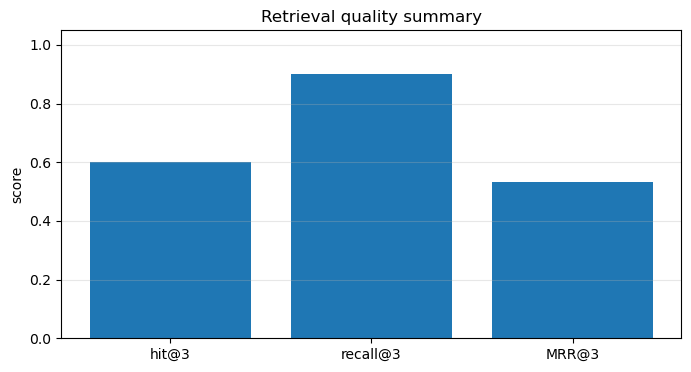

In [11]:
summary_df = pd.DataFrame(
    {
        "metric": list(metrics_summary.keys()),
        "value": list(metrics_summary.values()),
    }
)

plt.figure(figsize=(8, 4))
plt.bar(summary_df["metric"], summary_df["value"])
plt.ylim(0, 1.05)
plt.title("Retrieval quality summary")
plt.ylabel("score")
plt.grid(axis="y", alpha=0.3)
plt.show()


In [12]:
retrieval_eval_df.sort_values(["hit_at_k", "rank_of_first_relevant"], ascending=[True, True]).head(5)


,query,expected_source,retrieved_sources,retrieved_doc_ids,hit_at_k,recall_at_k,rank_of_first_relevant,mrr_at_k
1,Чем retrieval отличается от классификации?,doc_02,doc_06 | Метрики retrieval || doc_09 | Как раб...,"[doc_06, doc_09, doc_09]",0,0.0,NaN,0.0
2,Зачем делают чанкинг документов?,doc_03,doc_08 | Обновление базы знаний || doc_12 | За...,"[doc_08, doc_12, doc_05]",0,0.0,NaN,0.0
8,Из каких шагов состоит mini-RAG?,doc_09,doc_12 | Зачем возвращать источники || doc_12 ...,"[doc_12, doc_12, doc_05]",0,0.0,NaN,0.0
9,Почему важно возвращать источники?,doc_12,doc_04 | Что такое FAISS || doc_10 | Ограничен...,"[doc_04, doc_10, doc_08]",0,0.0,NaN,0.0
0,Что такое эмбеддинги текста?,doc_01,doc_01 | Что такое эмбеддинги || doc_02 | Поче...,"[doc_01, doc_02, doc_01]",1,2.0,1.0,1.0


## 5. Небольшой эксперимент с параметрами retrieval

Сделаем один аккуратный сравнительный эксперимент:  
сравним два значения `chunk_size` при фиксированном `overlap`.

Сравниваем:
- `chunk_size = 24`
- `chunk_size = 40`

Оцениваем по тем же контрольным запросам.


In [13]:
experiment_configs = [
    {"chunk_size": 24, "overlap": 8},
    {"chunk_size": 40, "overlap": 8},
]

experiment_rows = []
for cfg in experiment_configs:
    exp_artifacts = build_retriever(documents, chunk_size=cfg["chunk_size"], overlap=cfg["overlap"])
    exp_eval = evaluate_retrieval(exp_artifacts, benchmark_queries, top_k=top_k_eval)

    experiment_rows.append(
        {
            "chunk_size": cfg["chunk_size"],
            "overlap": cfg["overlap"],
            "num_chunks": len(exp_artifacts.chunks_df),
            f"hit@{top_k_eval}": exp_eval["hit_at_k"].mean(),
            f"recall@{top_k_eval}": exp_eval["recall_at_k"].mean(),
            f"MRR@{top_k_eval}": exp_eval["mrr_at_k"].mean(),
        }
    )

experiment_df = pd.DataFrame(experiment_rows)
experiment_df


,chunk_size,overlap,num_chunks,hit@3,recall@3,MRR@3
0,24,8,35,0.7,1.2,0.550000
1,40,8,23,0.7,1.1,0.583333


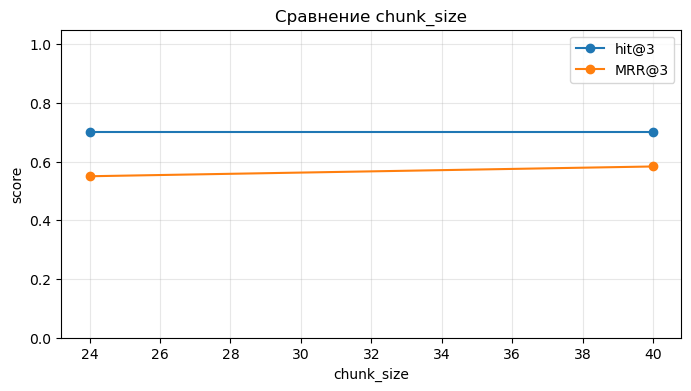

Лучший вариант в этом мини-эксперименте:


,chunk_size,overlap,num_chunks,hit@3,recall@3,MRR@3
1,40.0,8.0,23.0,0.7,1.1,0.583333


In [14]:
plt.figure(figsize=(8, 4))
plt.plot(experiment_df["chunk_size"], experiment_df[f"hit@{top_k_eval}"], marker="o", label=f"hit@{top_k_eval}")
plt.plot(experiment_df["chunk_size"], experiment_df[f"MRR@{top_k_eval}"], marker="o", label=f"MRR@{top_k_eval}")
plt.xlabel("chunk_size")
plt.ylabel("score")
plt.title("Сравнение chunk_size")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

best_row = experiment_df.sort_values([f"hit@{top_k_eval}", f"MRR@{top_k_eval}"], ascending=False).iloc[0]
print("Лучший вариант в этом мини-эксперименте:")
display(best_row.to_frame().T)


**Краткий вывод по эксперименту.**  
Изменение `chunk_size` влияет и на число чанков, и на то, насколько локальный контекст попадает в top-k.  
Для маленького учебного корпуса различия обычно умеренные, но эксперимент всё равно полезен: он показывает, что качество retrieval зависит не только от модели, но и от подготовки корпуса.


## 6. Обновление базы знаний и переиндексация

Добавим три новых документа. Они расширяют базу знаний фактами, которых раньше в ней не было:
- reranking;
- keyword search vs dense retrieval;
- hallucinations в RAG.

После этого заново выполним чанкинг и индексацию и сравним retrieval до и после обновления.


In [15]:
new_documents = [
    {
        "doc_id": "doc_13",
        "title": "Что такое reranking",
        "text": (
            "Reranking — это дополнительный этап после первичного retrieval. Сначала система извлекает top-k "
            "кандидатов быстрым retriever, а затем более точная модель переупорядочивает их. Reranking помогает "
            "поднять действительно релевантные фрагменты выше в выдаче, но делает конвейер тяжелее."
        ),
    },
    {
        "doc_id": "doc_14",
        "title": "Keyword search и dense retrieval",
        "text": (
            "Keyword search опирается на точные или почти точные совпадения слов. Dense retrieval опирается на "
            "векторные представления и может находить смыслово близкие фрагменты даже при разной лексике. "
            "На практике эти подходы иногда комбинируют, чтобы получить и точность по ключевым словам, и "
            "семантическую гибкость."
        ),
    },
    {
        "doc_id": "doc_15",
        "title": "Галлюцинации и роль контекста в RAG",
        "text": (
            "Одна из целей RAG — снизить риск галлюцинаций за счёт опоры на найденные источники. Но retrieval не "
            "гарантирует отсутствие ошибок: если контекст нерелевантен или неполон, ответ всё равно может быть "
            "неверным. Поэтому прозрачные источники и качественный retrieval остаются критически важными."
        ),
    },
]

updated_documents = documents + new_documents
print("Было документов:", len(documents))
print("Стало документов:", len(updated_documents))


Было документов: 12
Стало документов: 15


In [16]:
artifacts_before = build_retriever(documents, chunk_size=baseline_chunk_size, overlap=baseline_overlap)
artifacts_after = build_retriever(updated_documents, chunk_size=baseline_chunk_size, overlap=baseline_overlap)

before_after_queries = [
    "Что такое reranking?",
    "Чем keyword search отличается от dense retrieval?",
    "Как RAG помогает бороться с галлюцинациями?",
    "Что нужно сделать после обновления базы знаний?",
]

comparison_rows = []
for query in before_after_queries:
    before_df = search_chunks(query, artifacts_before, top_k=3)
    after_df = search_chunks(query, artifacts_after, top_k=3)

    before_sources = before_df["source"].tolist()
    after_sources = after_df["source"].tolist()

    comparison_rows.append(
        {
            "query": query,
            "before_retrieved_sources": " || ".join(before_sources),
            "after_retrieved_sources": " || ".join(after_sources),
            "changed": before_sources != after_sources,
        }
    )

before_after_df = pd.DataFrame(comparison_rows)
before_after_df


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Что такое reranking?,doc_10 | Ограничения учебного RAG || doc_11 | ...,doc_13 | Что такое reranking || doc_11 | Почем...,True
1,Чем keyword search отличается от dense retrieval?,doc_06 | Метрики retrieval || doc_09 | Как раб...,doc_14 | Keyword search и dense retrieval || d...,True
2,Как RAG помогает бороться с галлюцинациями?,doc_02 | Почему retrieval отличается от класси...,doc_02 | Почему retrieval отличается от класси...,False
3,Что нужно сделать после обновления базы знаний?,doc_10 | Ограничения учебного RAG || doc_10 | ...,doc_10 | Ограничения учебного RAG || doc_10 | ...,False


In [17]:
# На новых темах видно влияние обновления базы знаний
for query in before_after_queries[:3]:
    print("=" * 120)
    print("Запрос:", query)
    print("\nДо обновления:")
    display(search_chunks(query, artifacts_before, top_k=3)[["rank", "source", "score"]])
    print("\nПосле обновления:")
    display(search_chunks(query, artifacts_after, top_k=3)[["rank", "source", "score"]])


Запрос: Что такое reranking?

До обновления:


,rank,source,score
0,1,doc_10 | Ограничения учебного RAG,0.636420
1,2,doc_11 | Почему полезен overlap,0.522517
2,3,doc_11 | Почему полезен overlap,0.441255



После обновления:


,rank,source,score
0,1,doc_13 | Что такое reranking,0.735988
1,2,doc_11 | Почему полезен overlap,0.375437
2,3,doc_10 | Ограничения учебного RAG,0.349753


Запрос: Чем keyword search отличается от dense retrieval?

До обновления:


...

,rank,source,score
0,1,doc_14 | Keyword search и dense retrieval,0.800885
1,2,doc_06 | Метрики retrieval,0.351608
2,3,doc_09 | Как работает mini-RAG,0.313057


Запрос: Как RAG помогает бороться с галлюцинациями?

До обновления:


,rank,source,score
0,1,doc_02 | Почему retrieval отличается от класси...,0.490933
1,2,doc_03 | Зачем нужен чанкинг,0.490780
2,3,doc_09 | Как работает mini-RAG,0.425937



После обновления:


,rank,source,score
0,1,doc_02 | Почему retrieval отличается от класси...,0.493190
1,2,doc_03 | Зачем нужен чанкинг,0.441597
2,3,doc_09 | Как работает mini-RAG,0.426873


## 7. Mini-RAG

Соберём простой учебный mini-RAG:
1. получаем вопрос;
2. извлекаем top-k фрагментов;
3. собираем контекст;
4. формируем ответ по найденному контексту;
5. возвращаем ответ вместе с источниками.

Здесь генератор сделан намеренно простым и локальным:  
он выбирает предложения из retrieved-контекста, наиболее связанные с запросом.  
Для HW14 этого достаточно: важно показать понятный и воспроизводимый RAG-контур.


In [18]:
def split_sentences(text: str) -> List[str]:
    sentences = re.split(r"(?<=[.!?])\s+", text.strip())
    return [s.strip() for s in sentences if s.strip()]

def keyword_set(text: str) -> set[str]:
    tokens = re.findall(r"[а-яА-ЯёЁa-zA-Z0-9-]+", text.lower())
    stopwords = {
        "и", "в", "на", "с", "по", "для", "что", "это", "как", "а", "но", "или",
        "the", "is", "of", "to", "and", "in", "with", "for"
    }
    return {t for t in tokens if len(t) > 2 and t not in stopwords}

def generate_answer_from_context(question: str, retrieved_df: pd.DataFrame, max_sentences: int = 3) -> str:
    q_words = keyword_set(question)
    candidate_sentences = []

    for _, row in retrieved_df.iterrows():
        for sent in split_sentences(row["chunk_text"]):
            overlap_score = len(q_words & keyword_set(sent))
            candidate_sentences.append((overlap_score, sent, row["source"]))

    candidate_sentences = sorted(candidate_sentences, key=lambda x: x[0], reverse=True)

    selected = []
    used = set()
    for score, sent, source in candidate_sentences:
        if sent in used:
            continue
        used.add(sent)
        selected.append(sent)
        if len(selected) >= max_sentences:
            break

    if not selected:
        return "Не удалось построить ответ по найденному контексту."

    return " ".join(selected)

def mini_rag(question: str, artifacts: RetrievalArtifacts, top_k: int = 3) -> Dict[str, Any]:
    retrieved = search_chunks(question, artifacts, top_k=top_k)
    answer = generate_answer_from_context(question, retrieved, max_sentences=3)
    sources = retrieved["source"].tolist()
    return {
        "question": question,
        "answer": answer,
        "retrieved_sources": sources,
        "retrieved_df": retrieved,
    }


In [19]:
rag_questions = [
    "Почему чанкинг важен для retrieval и RAG?",
    "Какие метрики помогают оценивать retrieval?",
    "Что происходит после обновления базы знаний?",
    "Зачем в mini-RAG возвращать источники?",
    "Как top-k влияет на качество контекста?",
]

rag_examples = []
for question in rag_questions:
    result = mini_rag(question, artifacts_after, top_k=3)
    rag_examples.append(
        {
            "question": result["question"],
            "answer": result["answer"],
            "retrieved_sources": " || ".join(result["retrieved_sources"]),
        }
    )
    print("=" * 120)
    print("Вопрос:", result["question"])
    print("Ответ:", result["answer"])
    print("Источники:", ", ".join(result["retrieved_sources"]))
    display(result["retrieved_df"][["rank", "source", "score", "chunk_text"]])

rag_examples_df = pd.DataFrame(rag_examples)
rag_examples_df


Вопрос: Почему чанкинг важен для retrieval и RAG?
Ответ: Эти метрики подходят для retrieval лучше, чем обычные классификационные показатели. FAISS позволяет быстро возвращать top-k ближайших фрагментов и служит базовым инструментом для локального retrieval без внешней векторной базы. Для оценки retrieval нужен небольшой benchmark.
Источники: doc_06 | Метрики retrieval, doc_04 | Что такое FAISS, doc_05 | Контрольные запросы и benchmark


,rank,source,score,chunk_text
0,1,doc_06 | Метрики retrieval,0.608028,позицию первого релевантного ответа: чем он вы...
1,2,doc_04 | Что такое FAISS,0.420769,применять для поиска по косинусной близости. F...
2,3,doc_05 | Контрольные запросы и benchmark,0.341273,Для оценки retrieval нужен небольшой benchmark...


Вопрос: Какие метрики помогают оценивать retrieval?
Ответ: Эти метрики подходят для retrieval лучше, чем обычные классификационные показатели. Без контрольных запросов retrieval сложно оценивать инженерно. качество retrieval оценивают не accuracy, а метриками вроде hit@k, recall@k и MRR.
Источники: doc_06 | Метрики retrieval, doc_05 | Контрольные запросы и benchmark, doc_02 | Почему retrieval отличается от классификации


,rank,source,score,chunk_text
0,1,doc_06 | Метрики retrieval,0.667327,позицию первого релевантного ответа: чем он вы...
1,2,doc_05 | Контрольные запросы и benchmark,0.620387,документов. Даже маленький benchmark из 8–12 з...
2,3,doc_02 | Почему retrieval отличается от класси...,0.184996,"качество retrieval оценивают не accuracy, а ме..."


Вопрос: Что происходит после обновления базы знаний?
Ответ: полноте базы знаний. Из-за этого он чувствителен к формулировке запроса, качеству чанкинга и полноте базы знаний. В учебной работе важно показать результат до обновления и после него.
Источники: doc_10 | Ограничения учебного RAG, doc_10 | Ограничения учебного RAG, doc_08 | Обновление базы знаний


...

Вопрос: Зачем в mini-RAG возвращать источники?
Ответ: mini-RAG полезно показывать идентификаторы документов или названия источников вместе с ответом. Даже в учебном mini-RAG полезно показывать идентификаторы документов или названия источников Mini-RAG можно представить как цепочку: вопрос пользователя, retrieval релевантных чанков, сборка контекста, формирование ответа по найденным фрагментам и возврат источников.
Источники: doc_12 | Зачем возвращать источники, doc_12 | Зачем возвращать источники, doc_09 | Как работает mini-RAG


,rank,source,score,chunk_text
0,1,doc_12 | Зачем возвращать источники,0.774163,mini-RAG полезно показывать идентификаторы док...
1,2,doc_12 | Зачем возвращать источники,0.526817,Возврат источников — важная часть RAG-системы....
2,3,doc_09 | Как работает mini-RAG,0.419715,Mini-RAG можно представить как цепочку: вопрос...


Вопрос: Как top-k влияет на качество контекста?
Ответ: Поэтому top-k обычно подбирают как компромисс между полнотой и чистотой контекста. Mini-RAG можно представить как цепочку: вопрос пользователя, retrieval релевантных чанков, сборка контекста, формирование ответа по найденным фрагментам и возврат источников. Качество ответа зависит не только от генератора, но и от качества retrieval.
Источники: doc_07 | Влияние top-k на качество, doc_09 | Как работает mini-RAG, doc_02 | Почему retrieval отличается от классификации


,rank,source,score,chunk_text
0,1,doc_07 | Влияние top-k на качество,0.674177,но одновременно приносит лишние и дублирующиес...
1,2,doc_09 | Как работает mini-RAG,0.504303,Mini-RAG можно представить как цепочку: вопрос...
2,3,doc_02 | Почему retrieval отличается от класси...,0.364418,"качество retrieval оценивают не accuracy, а ме..."


,question,answer,retrieved_sources
0,Почему чанкинг важен для retrieval и RAG?,"Эти метрики подходят для retrieval лучше, чем ...",doc_06 | Метрики retrieval || doc_04 | Что так...
1,Какие метрики помогают оценивать retrieval?,"Эти метрики подходят для retrieval лучше, чем ...",doc_06 | Метрики retrieval || doc_05 | Контрол...
2,Что происходит после обновления базы знаний?,полноте базы знаний. Из-за этого он чувствител...,doc_10 | Ограничения учебного RAG || doc_10 | ...
3,Зачем в mini-RAG возвращать источники?,mini-RAG полезно показывать идентификаторы док...,doc_12 | Зачем возвращать источники || doc_12 ...
4,Как top-k влияет на качество контекста?,Поэтому top-k обычно подбирают как компромисс ...,doc_07 | Влияние top-k на качество || doc_09 |...


## 8. Краткий анализ ошибок и пограничных случаев

Ниже — несколько типичных неудачных или пограничных примеров:
- слишком общий запрос;
- запрос на тему, которая появилась только после обновления базы;
- ответ зависит от того, попал ли нужный фрагмент в top-k;
- генератор на основе извлечённых предложений может отвечать грубовато и не всегда красиво объединяет контекст.


In [20]:
error_case_questions = [
    "Как устроен production-grade RAG?",
    "Почему retrieval не равен генерации?",
    "Что делает reranking в сложной системе поиска?",
    "Как полностью избежать галлюцинаций в RAG?",
]

error_rows = []
for question in error_case_questions:
    result = mini_rag(question, artifacts_after, top_k=3)
    error_rows.append(
        {
            "question": question,
            "answer": result["answer"],
            "retrieved_sources": " || ".join(result["retrieved_sources"]),
        }
    )
    print("=" * 120)
    print("Вопрос:", question)
    print("Ответ:", result["answer"])
    print("Источники:", ", ".join(result["retrieved_sources"]))

error_cases_df = pd.DataFrame(error_rows)
error_cases_df


Вопрос: Как устроен production-grade RAG?
Ответ: Retrieval является отдельным инженерным слоем и часто используется как подготовительный этап перед генерацией ответа в RAG. качество retrieval оценивают не accuracy, а метриками вроде hit@k, recall@k и MRR. Mini-RAG можно представить как цепочку: вопрос пользователя, retrieval релевантных чанков, сборка контекста, формирование ответа по найденным фрагментам и возврат источников.
Источники: doc_02 | Почему retrieval отличается от классификации, doc_09 | Как работает mini-RAG, doc_07 | Влияние top-k на качество
Вопрос: Почему retrieval не равен генерации?
Ответ: Поэтому важно анализировать ошибки и явно отделять проблемы retrieval от проблем генерации. Без обновления индекс не знает о новых фактах, поэтому retrieval не сможет вернуть свежий источник. Но retrieval не гарантирует отсутствие ошибок: если контекст нерелевантен или неполон, ответ всё равно может быть неверным.
Источники: doc_08 | Обновление базы знаний, doc_10 | Ограничения уче

,question,answer,retrieved_sources
0,Как устроен production-grade RAG?,Retrieval является отдельным инженерным слоем ...,doc_02 | Почему retrieval отличается от класси...
1,Почему retrieval не равен генерации?,Поэтому важно анализировать ошибки и явно отде...,doc_08 | Обновление базы знаний || doc_10 | Ог...
2,Что делает reranking в сложной системе поиска?,поднять действительно релевантные фрагменты вы...,doc_13 | Что такое reranking || doc_13 | Что т...
3,Как полностью избежать галлюцинаций в RAG?,Одна из целей RAG — снизить риск галлюцинаций ...,doc_15 | Галлюцинации и роль контекста в RAG |...


**Краткие наблюдения по ошибкам:**
1. Если запрос слишком общий, retrieval вытягивает несколько частично подходящих фрагментов, и ответ получается расплывчатым.
2. Если в top-k не попал самый точный чанк, генератор собирает ответ по косвенным предложениям.
3. На новых темах после обновления retrieval заметно улучшается, потому что в базе появляются нужные документы.
4. Этот mini-RAG не делает полноценного abstractive generation, поэтому ответы иногда выглядят как склейка предложений из контекста.


## 9. Сохранение обязательных артефактов

- `retrieval_eval.csv`
- `rag_examples.csv`
- `retrieval_before_after_update.csv`

Дополнительно сохраним:
- `retrieval_metrics_summary.json`
- `retrieval_quality_plot.png`


In [21]:
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

retrieval_eval_to_save = retrieval_eval_df.copy()
retrieval_eval_to_save["retrieved_sources"] = retrieval_eval_to_save["retrieved_sources"].astype(str)
retrieval_eval_to_save.to_csv(artifacts_dir / "retrieval_eval.csv", index=False)

rag_examples_df.to_csv(artifacts_dir / "rag_examples.csv", index=False)
before_after_df.to_csv(artifacts_dir / "retrieval_before_after_update.csv", index=False)

with open(artifacts_dir / "retrieval_metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, ensure_ascii=False, indent=2)

plt.figure(figsize=(8, 4))
plt.bar(summary_df["metric"], summary_df["value"])
plt.ylim(0, 1.05)
plt.title("Retrieval quality summary")
plt.ylabel("score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(artifacts_dir / "retrieval_quality_plot.png", dpi=150)
plt.close()

print("Сохранённые файлы:")
for path in sorted(artifacts_dir.iterdir()):
    print("-", path.name)


Сохранённые файлы:
- rag_examples.csv
- retrieval_before_after_update.csv
- retrieval_eval.csv
- retrieval_metrics_summary.json
- retrieval_quality_plot.png


## 10. Итог

В ноутбуке реализованы все обязательные блоки HW14:
- загрузка и краткий анализ базы знаний;
- чанкинг;
- векторные представления;
- FAISS-индекс;
- retrieval по примерам;
- benchmark и метрики `hit@k`, `recall@k`, `MRR@k`;
- один сравнительный эксперимент по параметру `chunk_size`;
- обновление базы знаний и сравнение retrieval до/после;
- mini-RAG с ответами и источниками;
- краткий анализ ограничений;
- сохранение обязательных артефактов.
